In [7]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline  

# **Linguistic Pipeline in action 🦐**

Text_01_1115, St01_d **Il contadino astrologo**

In [9]:
with open ("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\data\\texts_1115\\01_1115.txt", 'r', encoding="utf-8")as infile:
    text = infile.read()

print(text[:500])

Il contadino astrologo.
Un Re aveva perduto un anello prezioso. Cerca qua, cerca là, non si trova. Mise fuori un bando che
se un astrologo gli sa dire dov'è, lo fa ricco per tutta la vita. C'era un contadino senza un soldo, che non sapeva né leggere né scrivere, e si chiamava Gàmbara. "Sarà tanto difficile far l'astrologo? - si disse. – Mi ci voglio provare". E andò dal Re che lo prese in parola, e lo chiuse a studiare in una stanza. Dove c'erano solo un letto e un tavolo con un gran libraccio d


## **First Step**
*.py file* = `nlp_pipeline/processor.py`

- tokenization
- mwe
- lemmatization
- PoS
- Deapparse/Consituency
- **Zipf's frequency**
- **Type of words (*content, function*)**
- AoA

- **Statistics of texts**

In [10]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\01_1115.csv", sep=";", encoding="utf-8")
df.head()

,token_id,sentence_ids,tokens_no_punct,lemma_no_punct,PoS,depparse,head,constituency,AoA(m+sd),Zipf_freq,type_of_words
0,1,0,il,il,DET,det,contadino,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"7,039560886",function
1,2,0,contadino,contadino,NOUN,root,ROOT,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"3,787520326",content
2,3,0,astrologo,astrologo,ADJ,amod,contadino,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"2,502677091",content
3,4,1,un,uno,DET,det,Re,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"7,065833912",function
4,5,1,re,re,NOUN,nsubj,perduto,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,4.24 ± 1.76,"5,011715611",content


## **Statistics on the text**
*.py file* = `nlp_pipeline/processor.py`


In [ ]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\summary_all_texts.csv")

df.head(1)


,text_id,num_tokens,num_sentences,num_types,TTR,TTR_lemmas,avg_sentence_length,Zipf_mean,percent_rare_words,Gulpease_index,num_function_words,num_content_words,num_verbs,num_adjectives,num_nouns,top_lemmas,top_bigrams
0,01_1115,519,41,261,0.503,0.374,15.24,5.29,12.75,70.37,287 (55.3%),229 (44.1%),102 (19.7%),22 (4.2%),105 (20.2%),"['il (7.1%)', 'e (5.2%)', 'essere (4.4%)', 'un...","['l anello (0.8%)', 'e si (0.6%)', 'l astrolog..."


## **4. Word Frequency**


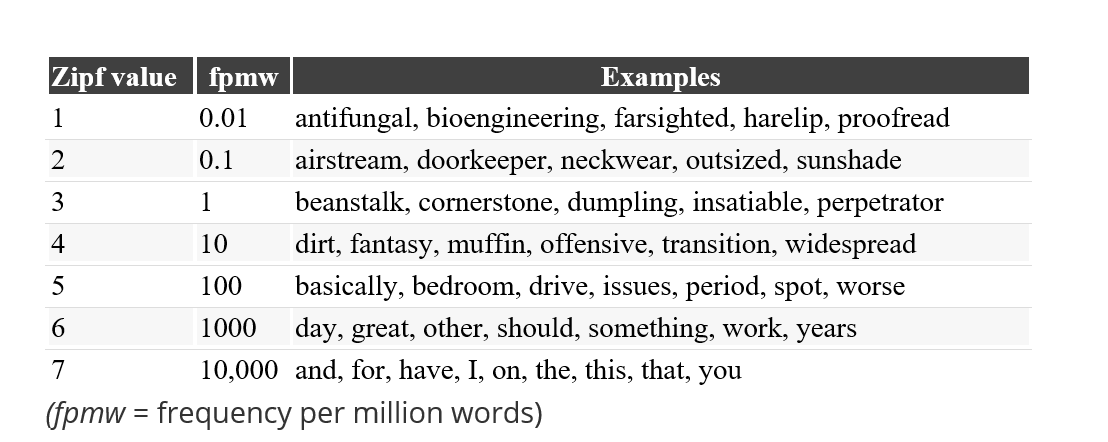

In [6]:
from IPython.display import Image
Image("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\doc\\Zipffreq.png")

c:\Users\schia\OneDrive - Alma Mater Studiorum Università di Bologna\Desktop\IMT\TESI\linguistic_pipeline_EEG\venv\Lib\site-packages\matplotlib\axes\_axes.py:7168: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


Text(0.5, 1.0, 'Zipf distribution of words')

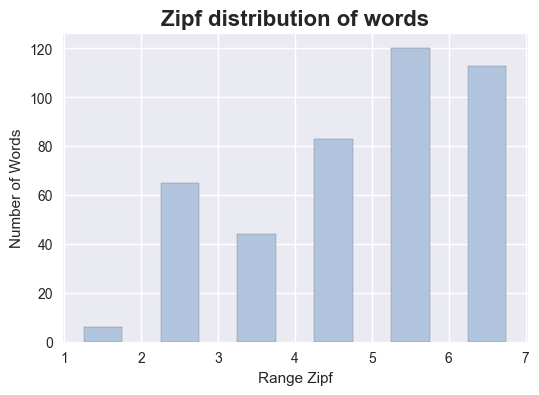

In [ ]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\01_1115.csv", sep=";", encoding="utf-8")
df["Zipf_freq"] = df["Zipf_freq"].str.replace(',', '.').astype(float)

# Definizione dei bin
bins = [1, 2, 3, 4, 5, 6, 7, float("inf")]

plt.figure(figsize=(6, 4))
plt.style.use("seaborn-v0_8")
plt.hist(df["Zipf_freq"], bins=bins, color="lightsteelblue", rwidth=0.5, edgecolor="gray")
plt.xlabel("Range Zipf")
plt.ylabel("Number of Words")
plt.title("Zipf distribution of words", fontsize=16, fontweight="bold")


c:\Users\schia\OneDrive - Alma Mater Studiorum Università di Bologna\Desktop\IMT\TESI\linguistic_pipeline_EEG\venv\Lib\site-packages\matplotlib\axes\_axes.py:7174: RuntimeWarning: invalid value encountered in add
  boffset += 0.5 * totwidth


Text(0.5, 1.0, 'Function vs Content Words distribution')

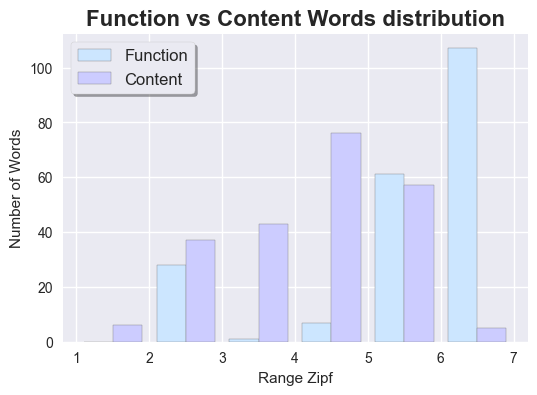

In [69]:
df_funzione = df[df["type_of_words"] == "function"]
df_contenuto = df[df["type_of_words"] == "content"]
plt.figure(figsize=(6, 4))

plt.hist(
    [df_funzione["Zipf_freq"], df_contenuto["Zipf_freq"]],
    bins=bins,
    color=[(204/255, 230/255, 255/255), (204/255, 204/255, 255/255)],
    label=["Function", "Content"], edgecolor="gray")

plt.xlabel("Range Zipf")
plt.ylabel("Number of Words")
plt.legend(fontsize=12, frameon=True, shadow=True)
plt.title("Function vs Content Words distribution", fontsize=16, fontweight="bold")


## **3. Lexical Entropy**

*.py file* = `nlp_pipeline/surprisal_entropy.py`


## **4. Semantic Dissimilarity**
*.py file* = `nlp_pipeline/semantic_dissimilarity.py`
